<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/05_inferencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas e modelos**
---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import urllib.request
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta
import json
import requests
import os
import openpyxl
from google.colab import files
import unicodedata

base = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main"

modelos = {}

for nome in ["RandomForest", "XGBoost", "LightGBM"]:
    !wget -O {nome}.joblib "{base}/{nome}.joblib"
    modelos[nome] = joblib.load(f"{nome}.joblib")

#ExtraTrees
url = 'https://github.com/fcoliveira-utfpr/aquacrop_ml/releases/download/6/ExtraTrees.joblib'
filename = 'ExtraTrees.joblib'
urllib.request.urlretrieve(url, filename)

--2026-04-11 12:45:46--  https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/RandomForest.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17815761 (17M) [application/octet-stream]
Saving to: ‘RandomForest.joblib’

RandomForest.joblib 100%[===================>]  16.99M  --.-KB/s    in 0.1s    

2026-04-11 12:45:46 (147 MB/s) - ‘RandomForest.joblib’ saved [17815761/17815761]

--2026-04-11 12:45:47--  https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/XGBoost.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting respons

('ExtraTrees.joblib', <http.client.HTTPMessage at 0x78c2c2bb1be0>)

# **Preparando dados**
---

In [ ]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/municipios_inferencia.csv"
df = pd.read_csv(url)
df.drop(columns=['system:index', '.geo', 'estado'], inplace=True)
df.rename(columns={
    "altitude_m": "Altitude",
    "municipio": "Municipio",
    "latitude": "Latitude",
    "longitude": "Longitude"
    }, inplace=True)
df_municipios = df
url1 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_milho_oeste.csv"
df1 = pd.read_csv(url1)
df_filtrado = df1[df1['Localidade'].isin(df_municipios['Municipio'])].copy().reset_index(drop=True)
df_filtrado.drop(columns=['Media', 'Meedia'], inplace=True)
df_f = df_filtrado.merge(
    df_municipios,
    left_on="Localidade",
    right_on="Municipio",
    how="left"
)
#df_f

# **Baixando dados**
---

In [ ]:
municipios = [
 'Céu Azul',
 'Medianeira',
 'Mercedes',
 'Palotina'
]

sem = ['05/02/', '15/02/', '25/02/', '05/03/', '15/03/', '25/03/']

anos = range(2007, 2023)

df_final = pd.DataFrame()

for municipio in municipios:

    for ano_inicial in anos:

        for data_sem in sem:

            try:
                estado = "PR"
                cultura = "Milho"

                # ============================================================
                # Carrega base climática local
                # ============================================================
                url_1 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/clima_solo_local.csv"
                df1 = pd.read_csv(url_1)

                # Separa colunas categóricas
                cidade = df1['Município']
                uf = df1['Estado']
                regiao = df1['Região']
                koppen = df1['Köppen']

                # Converte valores com vírgula para ponto e numérico
                df1_valores = df1.drop(columns=['Município', 'Estado','Região','Köppen'])
                df1_valores = df1_valores.replace({',': '.'}, regex=True)
                df1_valores = df1_valores.apply(pd.to_numeric, errors='coerce')

                # Reconstrói o df
                df1 = df1_valores.copy()
                df1['Município'] = cidade
                df1['Estado'] = uf
                df1['Região'] = regiao
                df1['Köppen'] = koppen

                # ============================================================
                # Carrega base das culturas
                # ============================================================
                url_2 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/dados_culturas.csv"
                df2 = pd.read_csv(url_2)

                # Separa cultura
                cult = df2['Cultura']
                df2 = df2.drop(columns=['Cultura'])

                # Converte texto para numérico
                df2_valores = df2.replace({',': '.'}, regex=True)
                df2_valores = df2_valores.apply(pd.to_numeric, errors='coerce')
                df2 = df2_valores.copy()
                df2['Cultura'] = cult

                # Filtra a cultura escolhida
                df2 = df2[(df2['Cultura'] == cultura)].copy()

                # Filtra município e estado
                df11 = df1[(df1['Município'] == municipio) & (df1['Estado'] == estado)].copy()

                # Variável do solo
                DTA = df11['DTA (mm/m)'].iloc[0]

                # Duração total da cultura
                duracao_do_ciclo = 100  # dias
                CIAFmax = 0.5
                Cc = (0.35 + 0.45)/2 # Doorenbos & Kassam (1994)
                U = (10 + 13)/2 # Doorenbos & Kassam (1994)

                # % de duração das fases
                fase1 = df2['F1 %'].iloc[0]
                fase2 = df2['F2 %'].iloc[0]
                fase3 = df2['F3 %'].iloc[0]
                fase4 = df2['F4 %'].iloc[0]

                # Kc nas fases
                kc1 = df2['Kc ini'].iloc[0]
                kc2 = df2['Kc méd'].iloc[0]
                kc3 = df2['Kc fin'].iloc[0]

                ky1 = df2['ky1'].iloc[0]
                ky2 = df2['ky2'].iloc[0]
                ky3 = df2['ky3'].iloc[0]
                ky4 = df2['ky4'].iloc[0]

                # Profundidade radicular
                z_inicial = 0.05
                z_final = df2['Z efetivo (m)'].iloc[0]

                # Metadados do local
                nome_cidade = df11["Município"].iloc[0]
                latitude = df11["latitude"].iloc[0]
                longitude = df11["longitude"].iloc[0]
                alt = df11["Altitude"].iloc[0]

                # ============================================================
                # Download de dados NASA POWER
                # ============================================================

                # Define período de coleta
                ano_final = ano_inicial+1
                data_ini = datetime(ano_inicial, 1, 1).date()
                data_fim = datetime(ano_final, 12, 31).date()

                # Formata datas para API
                ini = int(data_ini.strftime('%Y%m%d'))
                fin = int(data_fim.strftime('%Y%m%d'))

                # Monta URL da requisição
                base_url = (
                    "https://power.larc.nasa.gov/api/temporal/daily/point"
                    "?parameters=T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,TOA_SW_DWN"
                    "&community=RE"
                    "&longitude={longitude}"
                    "&latitude={latitude}"
                    "&start={ini}"
                    "&end={fin}"
                    "&format=JSON"
                )

                api_request_url = base_url.format(
                    longitude=longitude,
                    latitude=latitude,
                    ini=ini,
                    fin=fin
                )

                # Requisição
                response = requests.get(url=api_request_url, verify=True, timeout=120)
                response.raise_for_status()

                # Extração dos parâmetros
                dados_json = response.json()
                propriedades = dados_json['properties']
                parametros = propriedades['parameter']

                # Datas
                datas_str = sorted(list(parametros['T2M_MIN'].keys()))
                datas = [pd.to_datetime(d) for d in datas_str]

                # Constrói DataFrame com variáveis
                df = pd.DataFrame({'Data': datas})
                df['Tmin'] = [parametros['T2M_MIN'][d] for d in datas_str]
                df['Tmax'] = [parametros['T2M_MAX'][d] for d in datas_str]
                df['Chuva'] = [parametros['PRECTOTCORR'][d] for d in datas_str]
                df['UR'] = [parametros['RH2M'][d] for d in datas_str]
                df['U2'] = [parametros['WS2M'][d] for d in datas_str]
                df['Rs_raw'] = [parametros['ALLSKY_SFC_SW_DWN'][d] for d in datas_str]
                df['Qo_raw'] = [parametros['TOA_SW_DWN'][d] for d in datas_str]

                # Converte radiação para MJ/m²
                df['Rs'] = df['Rs_raw'] * 3.6
                df['Qo'] = df['Qo_raw'] * 3.6

                # Variáveis intermediárias
                df['Tmed'] = (df['Tmax'] + df['Tmin']) / 2
                df['Patm'] = 101.3 * ((293 - 0.0065 * alt) / 293) ** 5.26
                df['NDA'] = [pd.to_datetime(d).timetuple().tm_yday for d in df['Data']]

                # Declinação solar
                def dec_sol(NDA):
                    return 23.45 * np.sin(np.deg2rad(360/365 * (NDA - 80)))

                df['d'] = df['NDA'].apply(dec_sol)

                # Hora de nascer do sol
                def hora_na_sol(d, Lat):
                    return np.rad2deg(np.arccos(-(np.tan(np.deg2rad(Lat)) * np.tan(np.deg2rad(d)))))

                df['Hn'] = df['d'].apply(lambda d_: hora_na_sol(d_, latitude))


                # (d/D)^2
                def relacao_d_D_2(NDA):
                    return 1 + 0.033 * np.cos(np.deg2rad(NDA * 360/365))
                df['(d/D)²'] = df['NDA'].apply(relacao_d_D_2)

                # Balanços radiativos
                df['BOC'] = df['Rs'] * 0.75  # (1 - 25%)

                df['N'] = df.apply(lambda x: (2 * x['Hn']) / 15, axis = 1)

                #determinando a insolação - n
                df['n_inso'] = df.apply(lambda x: (((x['Rs']/x['Qo'])  - (0.29 * np.cos(latitude)))/0.52) * x['N'], axis=1)

                def e_saturacao(temp):
                    return 0.6108 * 10 ** ((7.5 * temp) / (237.3 + temp))

                df['es_Tmax'] = df['Tmax'].apply(e_saturacao)
                df['es_Tmin'] = df['Tmin'].apply(e_saturacao)
                df['es'] = (df['es_Tmax'] + df['es_Tmin']) / 2
                df['ea'] = (df['UR']/100) * df['es']
                df['QGcs'] = df['Qo'] * (0.75 + (2e-5)*alt)

                def BOL(tmax, tmin, eaa, qg, qgcs):
                    a = 4.903e-9 * (((tmax+273.16)**4 + (tmin+273.16)**4)/2)
                    b = (0.34 - 0.14*np.sqrt(eaa))
                    c = 1.35*(qg/qgcs) - 0.35
                    return -(a*b*c)

                df['BOL'] = df.apply(lambda x: BOL(x['Tmax'],x['Tmin'],x['ea'],x['Rs'],x['QGcs']), axis=1)
                df['Rn'] = df['BOC'] + df['BOL']

                df['s'] = (4098 * df['es']) / (df['Tmed'] + 237.3)**2
                df['gama'] = 0.665e-3 * df['Patm']

                # Penman-Monteith
                def ETo(s,Rn,gama,u2,es,ea,tmed):
                    ETo1 = 0.408*s*Rn
                    ETo2 = (gama*900*u2*(es-ea))/(tmed+273)
                    ETo3 = s + gama*(1+0.34*u2)
                    return (ETo1 + ETo2)/ETo3

                df['ETo'] = df.apply(lambda x: ETo(x['s'],x['Rn'],x['gama'],x['U2'],x['es'],x['ea'],x['Tmed']), axis=1)

                # Metadados no df
                df['Municipio'] = nome_cidade
                df['Lat'] = latitude
                df['Lon'] = longitude
                df['Alt'] = alt

                df.replace(-999, np.nan, inplace=True)
                df.interpolate(inplace=True)

                # ============================================================
                # Fases fenológicas da cultura
                # ============================================================

                fasetotal = fase1 + fase2 + fase3 + fase4
                fase1d = (duracao_do_ciclo * fase1)/fasetotal
                fase2d = (duracao_do_ciclo * fase2)/fasetotal
                fase3d = (duracao_do_ciclo * fase3)/fasetotal
                fase4d = (duracao_do_ciclo * fase4)/fasetotal

                # Incrementos de Kc e Z
                acrescimo_kc1 = (kc2 - kc1)/fase2d
                acrescimo_kc2 = (kc3 - kc2)/fase4d
                acrescimo_z = (z_final - z_inicial)/(fase1d + fase2d)

                # ============================================================
                # Datas de semeadura e maturação
                # ============================================================

                data_semeadura = datetime.strptime(f'{data_sem}{ano_inicial}', '%d/%m/%Y')
                data_maturacao = data_semeadura + timedelta(days=duracao_do_ciclo-1)

                df1 = pd.DataFrame({
                    'Datas de semeadura': [data_semeadura],
                    'Datas maturação': [data_maturacao]
                })

                #**************SIMULAÇÃO DE PRODUTIVIDADE**************************************************
                safra1 = (df.loc[(df['Data'] >= df1['Datas de semeadura'][0]) & (df['Data'] <= df1['Datas maturação'][0])]).copy()

                safra1['n'] = list(range(1, safra1['NDA'].count() +1))

                # -------------------------------
                # 1) Kc e FASE da cultura (igual prof)
                # -------------------------------
                fase_cultura = []
                Kc1 = []

                for n in safra1['n']:
                    if n <= fase1d:
                        # Fase 1: Kc = kc1
                        Kc1.append(kc1)
                        fase_cultura.append(1)

                    elif n <= fase1d + fase2d:
                        # Fase 2: crescimento linear kc1 -> kc2
                        Kc1.append(Kc1[-1] + acrescimo_kc1)
                        fase_cultura.append(2)

                    elif n <= fase1d + fase2d + fase3d:
                        # Fase 3: Kc constante = kc2
                        Kc1.append(kc2)
                        fase_cultura.append(3)

                    else:
                        # Fase 4: decaimento linear kc2 -> kc3
                        Kc1.append(Kc1[-1] + acrescimo_kc2)
                        fase_cultura.append(4)

                safra1['Kc'] = Kc1
                safra1['Fase'] = fase_cultura

                # -------------------------------
                # 2) Crescimento da raiz z
                # -------------------------------
                z1 = []
                for n in safra1['n']:
                    if n == 1:
                        z1.append(z_inicial + acrescimo_z)
                    elif n <= fase1d + fase2d:
                        z1.append(z1[-1] + acrescimo_z)
                    else:
                        z1.append(z_final)

                safra1['z'] = z1

                # -------------------------------
                # 3) CAD, ETc, P-ETc
                # -------------------------------
                safra1['CAD'] = safra1['z'] * DTA          # CAD (mm) no perfil explorado
                safra1['ETc'] = safra1['Kc'] * safra1['ETo']    # ETc diária
                safra1['P-ETc'] = safra1['Chuva'] - safra1['ETc']

                # -------------------------------
                # 4) ARM (armazenamento de água no solo)
                # -------------------------------
                PETc1 = safra1['P-ETc'].to_numpy()
                CAD1 = safra1['CAD'].to_numpy()

                # Estado inicial de ARM (solo cheio na profundidade inicial)
                ARM1 = [z_inicial * DTA]

                for p, cad in zip(PETc1, CAD1):
                    prev = ARM1[-1]
                    if p < 0:
                        # Déficit: usa equação exponencial (igual professor)
                        ARM1.append(prev * np.exp(p / cad))
                    elif p + prev >= cad:
                        # Encharcou: limita ao CAD
                        ARM1.append(cad)
                    else:
                        # Situação normal
                        ARM1.append(prev + p)

                # Remove o estado inicial e deixa só os valores correspondentes aos dias
                ARM1 = ARM1[1:]
                safra1['ARM'] = ARM1

                # -------------------------------
                # 5) ALT (variação diária de ARM)
                # -------------------------------
                ALT = [0]  # primeiro dia, variação zero
                ALT += list(np.array(ARM1[1:]) - np.array(ARM1[:-1]))
                safra1['ALT'] = ALT

                # -------------------------------
                # 6) ETR, DEF, EXC, ISNA diário
                # -------------------------------
                safra1['ETR'] = np.where(
                    safra1['P-ETc'] < 0,
                    safra1['Chuva'] + safra1['ALT'].abs(),  # solo complementa a chuva
                    safra1['ETc']                           # sem limitação hídrica
                )

                safra1['DEF'] = safra1['ETc'] - safra1['ETR']

                safra1['EXC'] = np.where(
                    safra1['ARM'] < safra1['CAD'],
                    0,
                    safra1['P-ETc'] - safra1['ALT']
                )

                safra1['ISNA_diario'] = safra1['ETR'] / safra1['ETc']

                safra1['n/N'] = safra1.apply(lambda x: x['n_inso']/x['N'], axis=1)

                safra1['qo'] = safra1.apply(lambda x: x['Qo'] * 23.9234, axis=1)

                safra1['cTc'] = safra1.apply(lambda x: -4.16 + (0.4325 * x['Tmed']) - (0.00725 * (x['Tmed'])**2), axis=1)

                safra1['cTn'] = safra1.apply(lambda x: -1.064 + (0.173 * x['Tmed']) + (0.0029 * (x['Tmed'])**2), axis=1)

                safra1['PPBp'] = safra1.apply(
                    lambda x: ((107.2 + 0.36 * x['qo']) * x['cTc'] * x['n/N']) +
                              ((31.7 + 0.219 * x['qo']) * x['cTn'] * (1 - x['n/N'])),
                    axis=1
                )

                # correção aqui
                safra1['CR'] = np.where(safra1['Tmed'] >= 20, 0.5, 0.6)

                safra1['PP'] = (safra1['PPBp'] * CIAFmax * safra1['CR'] * Cc)/(1 - 0.01 * U)

                Bp = safra1['PP'].sum()

                def rc(safra):

                    rc_1 = safra['ETR'][0:int(fase1d)].sum() / safra['ETc'][0:int(fase1d)].sum()

                    rc_2 = safra['ETR'][int(fase1d):int(fase1d + fase2d)].sum() / \
                          safra['ETc'][int(fase1d):int(fase1d + fase2d)].sum()

                    rc_3 = safra['ETR'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum()

                    rc_4 = safra['ETR'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum()

                    return [rc_1, rc_2, rc_3, rc_4]


                rc_vals = rc(safra1)

                rc_1, rc_2, rc_3, rc_4 = rc_vals

                PA1 = (1 - ky1 * (1 - rc_1)) * Bp
                PA2 = (1 - ky2 * (1 - rc_2)) * PA1
                PA3 = (1 - ky3 * (1 - rc_3)) * PA2
                PA4 = (1 - ky4 * (1 - rc_4)) * PA3


                # -----------------------------------------
                # Resumo por fase das principais variáveis
                # -----------------------------------------

                safra = safra1.groupby("Fase").agg({
                    "Tmin": "mean",
                    "Tmax": "mean",
                    "Tmed": "mean",
                    "Chuva": "sum",
                    "UR": "mean",
                    "ETc": "sum",
                    'ETR': "sum",
                    "ARM": "last",
                    "DEF": "sum",
                    "EXC": "sum",
                    "N": "mean",
                    "PP": "sum"
                })
                safra['Data semeadura'] = df1['Datas de semeadura'].iloc[0]
                safra['Data maturação'] = df1['Datas maturação'].iloc[0]

                safra = safra.reset_index()
                safra['ISNA'] = [rc_1, rc_2, rc_3, rc_4]
                safra['PA'] = [PA1, PA2, PA3, PA4]

                safra

                # ------------------------------------------------
                # RESULTADO FINAL
                # ------------------------------------------------

                safra['Municipio'] = municipio
                safra['Ano'] = ano_inicial

                df_final = pd.concat([df_final, safra], ignore_index=True)
                print(f"OK -> {municipio} {ano_inicial} {data_sem}")

            except:
                print(f"ERRO -> {municipio} {ano_inicial} {data_sem}")

/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Céu Azul 2007 05/02/


/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Céu Azul 2007 15/02/


/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


...

/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Palotina 2022 05/03/


/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Palotina 2022 15/03/
OK -> Palotina 2022 25/03/


/tmp/ipykernel_11727/2079476914.py:232: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


In [ ]:
df_final.to_csv('df_final_inferencia.csv', index=False)

# **Feature engineering**
---

In [ ]:
# ===============================
# 1. FUNÇÃO PARA NORMALIZAR TEXTO
# ===============================

def normalize_text(text):
    text = str(text).strip().upper()
    text = unicodedata.normalize('NFKD', text)
    text = ''.join([c for c in text if not unicodedata.combining(c)])
    return text

# ===============================
# 2. CARREGAR DADOS
# ===============================

url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_final_inferencia.csv"
df = pd.read_csv(url)

# ===============================
# 3. FEATURE ENGINEERING
# ===============================

df["Amp"] = df['Tmax'] - df['Tmin']
df["Pefetiva"] = df["Chuva"] / df['ETc']
df['T_DEF'] = df['Tmax'] * df['DEF']

# ===============================
# 4. PREPARAR YIELD
# ===============================

df_yield = df_f.melt(
    id_vars=['Municipio','Latitude','Longitude','Altitude'],
    value_vars=[str(y) for y in range(2007, 2022)],
    var_name='Ano',
    value_name='Yield_obs'
)
df_yield['lat_lon'] = df_yield['Latitude'] * df_yield['Longitude']

# ===============================
# 5. PADRONIZAÇÃO (CRÍTICO)
# ===============================

df['Municipio'] = df['Municipio'].apply(normalize_text)
df_yield['Municipio'] = df_yield['Municipio'].apply(normalize_text)

df['Ano'] = df['Ano'].astype(int)
df_yield['Ano'] = df_yield['Ano'].astype(int)

# ===============================
# 6. FILTRAR MUNICÍPIOS
# ===============================

municipios = ['CEU AZUL','MEDIANEIRA','MERCEDES','PALOTINA']

df = df[df['Municipio'].isin(municipios)]
df_yield = df_yield[df_yield['Municipio'].isin(municipios)]

# ===============================
# 7. MERGE
# ===============================

df_model = df.merge(df_yield, on=['Municipio','Ano'], how='left')

# ===============================
# 8. DATAS → DOY
# ===============================

df_model['Data semeadura'] = pd.to_datetime(df_model['Data semeadura'])
df_model['Data maturação'] = pd.to_datetime(df_model['Data maturação'])

df_model['DOY_semeadura'] = df_model['Data semeadura'].dt.dayofyear
df_model['DOY_maturacao'] = df_model['Data maturação'].dt.dayofyear

df_model = df_model.drop(columns=['Data semeadura', 'Data maturação'])

# ===============================
# 9. VARIÁVEIS POR FASE
# ===============================

vars_fase = [
    'Tmin','Tmax','Tmed','Chuva','UR','ETc','ETR','ARM',
    'DEF','EXC','ISNA','PA','Amp','Pefetiva','Latitude',
    'Longitude','Altitude','T_DEF','lat_lon'
]

# ===============================
# 10. IDENTIFICAR REPETIÇÕES
# ===============================

df_model['rep'] = df_model.groupby(
    ['Municipio','Ano','DOY_semeadura','DOY_maturacao','Fase']
).cumcount()

# ===============================
# 11. PIVOT (CORRETO)
# ===============================

df_wide = df_model.pivot(
    index=['Municipio','Ano','DOY_semeadura','DOY_maturacao','rep'],
    columns='Fase',
    values=vars_fase
)

# renomear colunas
df_wide.columns = [f'{v}_F{f}' for v, f in df_wide.columns]

df_wide = df_wide.reset_index()
df_wide = df_wide[(df_wide['Ano'] >= 2007) & (df_wide['Ano'] <= 2021)]

# ===============================
# 12. ADICIONAR YIELD
# ===============================

df_yield_unique = df_model[['Municipio','Ano','Yield_obs']].drop_duplicates()

df_wide = df_wide.merge(
    df_yield_unique,
    on=['Municipio','Ano'],
    how='left'
)

# ===============================
# 13. LIMPEZA FINAL
# ===============================

df_wide.drop(columns=[
    'Municipio',
    'Altitude_F2','Altitude_F3','Altitude_F4',
    'Latitude_F2','Latitude_F3','Latitude_F4',
    'Longitude_F2','Longitude_F3','Longitude_F4',
    'lat_lon_F2', 'lat_lon_F3', 'lat_lon_F4'
], inplace=True, errors='ignore')

df_wide = df_wide[(df_wide['Ano'] >= 2007) & (df_wide['Ano'] <= 2021)]

# ===============================
# 14. CHECK FINAL
# ===============================

print("Shape final:", df_wide.shape)

print("\nNaN em Yield por ano:")
print(df_wide.groupby('Ano')['Yield_obs'].apply(lambda x: x.isna().sum()))

print("\nResumo NaN geral:")
print(df_wide.isna().sum().sort_values(ascending=False).head(10))

Shape final: (450, 69)

NaN em Yield por ano:
Ano
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
Name: Yield_obs, dtype: int64

Resumo NaN geral:
Ano              0
DOY_semeadura    0
DOY_maturacao    0
rep              0
Tmin_F1          0
Tmin_F2          0
Tmin_F3          0
Tmin_F4          0
Tmax_F1          0
Tmax_F2          0
dtype: int64


In [ ]:
df_wide.to_csv('df_wide_inferencia.csv', index=False)

# **Inferencia dos modelos**

In [ ]:
modelo_et = joblib.load('ExtraTrees.joblib')
modelo_rf = joblib.load("RandomForest.joblib")
modelo_xgb = joblib.load("XGBoost.joblib")
modelo_lgbm = joblib.load("LightGBM.joblib")

features = ['UR_F1', 'T_DEF_F1', 'DEF_F1', 'Tmax_F1', 'Tmed_F2', 'Tmed_F1',
       'Tmax_F2', 'UR_F2', 'ISNA_F1', 'Tmin_F2', 'Tmin_F3', 'T_DEF_F2',
       'ETc_F1', 'DEF_F2', 'Altitude_F1', 'Amp_F4', 'Tmin_F1', 'Pefetiva_F1',
       'PA_F2', 'Tmed_F3', 'Chuva_F1', 'Tmin_F4', 'ISNA_F2', 'PA_F3', 'EXC_F1',
       'Longitude_F1', 'PA_F4', 'Amp_F3', 'Chuva_F2', 'ARM_F1', 'ETR_F4',
       'EXC_F2', 'ETR_F2', 'Pefetiva_F2', 'ARM_F3', 'Tmed_F4', 'ARM_F2',
       'Tmax_F3', 'ETc_F2', 'ETR_F1', 'Amp_F1', 'Latitude_F1', 'ETR_F3',
       'UR_F4', 'T_DEF_F4', 'DEF_F4', 'ISNA_F3', 'Pefetiva_F4', 'ISNA_F4',
       'UR_F3', 'Tmax_F4', 'lat_lon_F1', 'EXC_F3', 'ETc_F3', 'ETc_F4', 'PA_F1',
       'Chuva_F3', 'ARM_F4', 'DEF_F3', 'Chuva_F4', 'Amp_F2', 'EXC_F4',
       'Pefetiva_F3', 'T_DEF_F3', 'DOY_semeadura', 'DOY_maturacao']

In [ ]:
# Mapeamento altitude -> município
map_alt_mun = {
    465: 'Céu Azul',
    401: 'Medianeira',
    326: 'Mercedes',
    300: 'Palotina'
}

# lista de DOY e datas equivalentes
doy_sem = [36, 46, 56, 64, 74, 84]
datas = ['05/02', '15/02', '25/02', '05/03', '15/03', '25/03']

# criar dicionário
map_doy_data = dict(zip(doy_sem, datas))

resultados = []

doy_sem = [36, 46, 56, 64, 74, 84]

# LOOP POR MUNICÍPIO
for alt, municipio in map_alt_mun.items():

    df_mun = df_wide[df_wide['Altitude_F1'] == alt]

    # LOOP POR DATA
    for data in doy_sem:

        df_datas = df_mun[df_mun['DOY_semeadura'] == data].copy()

        # ⚠️ evitar erro se não tiver dados
        if df_datas.empty:
            continue

        df_datas.drop(columns=['Ano'], inplace=True, errors='ignore')

        # FEATURES
        X_novo = df_datas[features]

        # TARGET
        y_novo = df_datas['Yield_obs']

        # PREDIÇÃO
        y_pred = modelo_et.predict(X_novo)

        # MÉTRICAS
        mae = mean_absolute_error(y_novo, y_pred)
        mse = mean_squared_error(y_novo, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_novo, y_pred)
        mape = np.mean(np.abs((y_novo - y_pred) / (y_novo + 1e-6))) * 100

        # SALVAR RESULTADOS
        resultados.append({
            'Municipio': municipio,
            'Altitude': alt,
            'DOY': data,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'MAPE (%)': mape
        })

# DATAFRAME FINAL
df_resultados = pd.DataFrame(resultados)

# ordenar bonitinho
df_resultados = df_resultados.sort_values(['Municipio', 'DOY'])
# adicionar coluna no dataframe
df_resultados['Data_semeadura'] = df_resultados['DOY'].map(map_doy_data)

df_resultados

,Municipio,Altitude,DOY,MAE,MSE,RMSE,R2,MAPE (%),Data_semeadura
0,Céu Azul,465,36,211.543658,56652.620760,238.018110,0.831847,5.894003,05/02
1,Céu Azul,465,46,184.028224,47774.441178,218.573652,0.858199,5.194398,15/02
2,Céu Azul,465,56,208.398939,58173.734522,241.192319,0.827332,6.232719,25/02
3,Céu Azul,465,64,187.223360,48085.212805,219.283408,0.663105,5.255396,05/03
4,Céu Azul,465,74,230.834200,65363.123384,255.662127,0.542052,6.545237,15/03
5,Céu Azul,465,84,200.562001,55297.127038,235.153412,0.612577,5.722709,25/03
6,Medianeira,401,36,135.755490,50810.064880,225.410880,0.929004,3.908823,05/02
7,Medianeira,401,46,114.460485,31782.903570,178.277603,0.955590,3.435928,15/02
8,Medianeira,401,56,113.504792,17158.370776,130.989964,0.976025,4.070026,25/02
9,Medianeira,401,64,110.459938,23627.665428,153.712932,0.963502,3.251575,05/03


In [ ]:
df_resultados.to_csv('resultados_inferencia.csv', index=False)

#Imagens

In [ ]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/resultados_inferencia.csv"
df_infe = pd.read_csv(url)
df_infe

,Municipio,Altitude,DOY,MAE,MSE,RMSE,R²,MAPE,Data_semeadura
0,Céu Azul,465,36,211.543658,56652.620760,238.018110,0.831847,5.894003,05/02
1,Céu Azul,465,46,184.028224,47774.441178,218.573652,0.858199,5.194398,15/02
2,Céu Azul,465,56,208.398939,58173.734522,241.192319,0.827332,6.232719,25/02
3,Céu Azul,465,64,187.223360,48085.212805,219.283408,0.663105,5.255396,05/03
4,Céu Azul,465,74,230.834200,65363.123384,255.662127,0.542052,6.545237,15/03
5,Céu Azul,465,84,200.562001,55297.127038,235.153412,0.612577,5.722709,25/03
6,Medianeira,401,36,135.755490,50810.064880,225.410880,0.929004,3.908823,05/02
7,Medianeira,401,46,114.460485,31782.903570,178.277603,0.955590,3.435928,15/02
8,Medianeira,401,56,113.504792,17158.370776,130.989964,0.976025,4.070026,25/02
9,Medianeira,401,64,110.459938,23627.665428,153.712932,0.963502,3.251575,05/03


/tmp/ipykernel_11727/2540862912.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = df_heat.applymap(lambda x: f"{x:.2f}".replace('.', ','))
/tmp/ipykernel_11727/2540862912.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = df_heat.applymap(lambda x: f"{x:.2f}".replace('.', ','))
/tmp/ipykernel_11727/2540862912.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = df_heat.applymap(lambda x: f"{x:.2f}".replace('.', ','))
/tmp/ipykernel_11727/2540862912.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = df_heat.applymap(lambda x: f"{x:.2f}".replace('.', ','))
/tmp/ipykernel_11727/2540862912.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


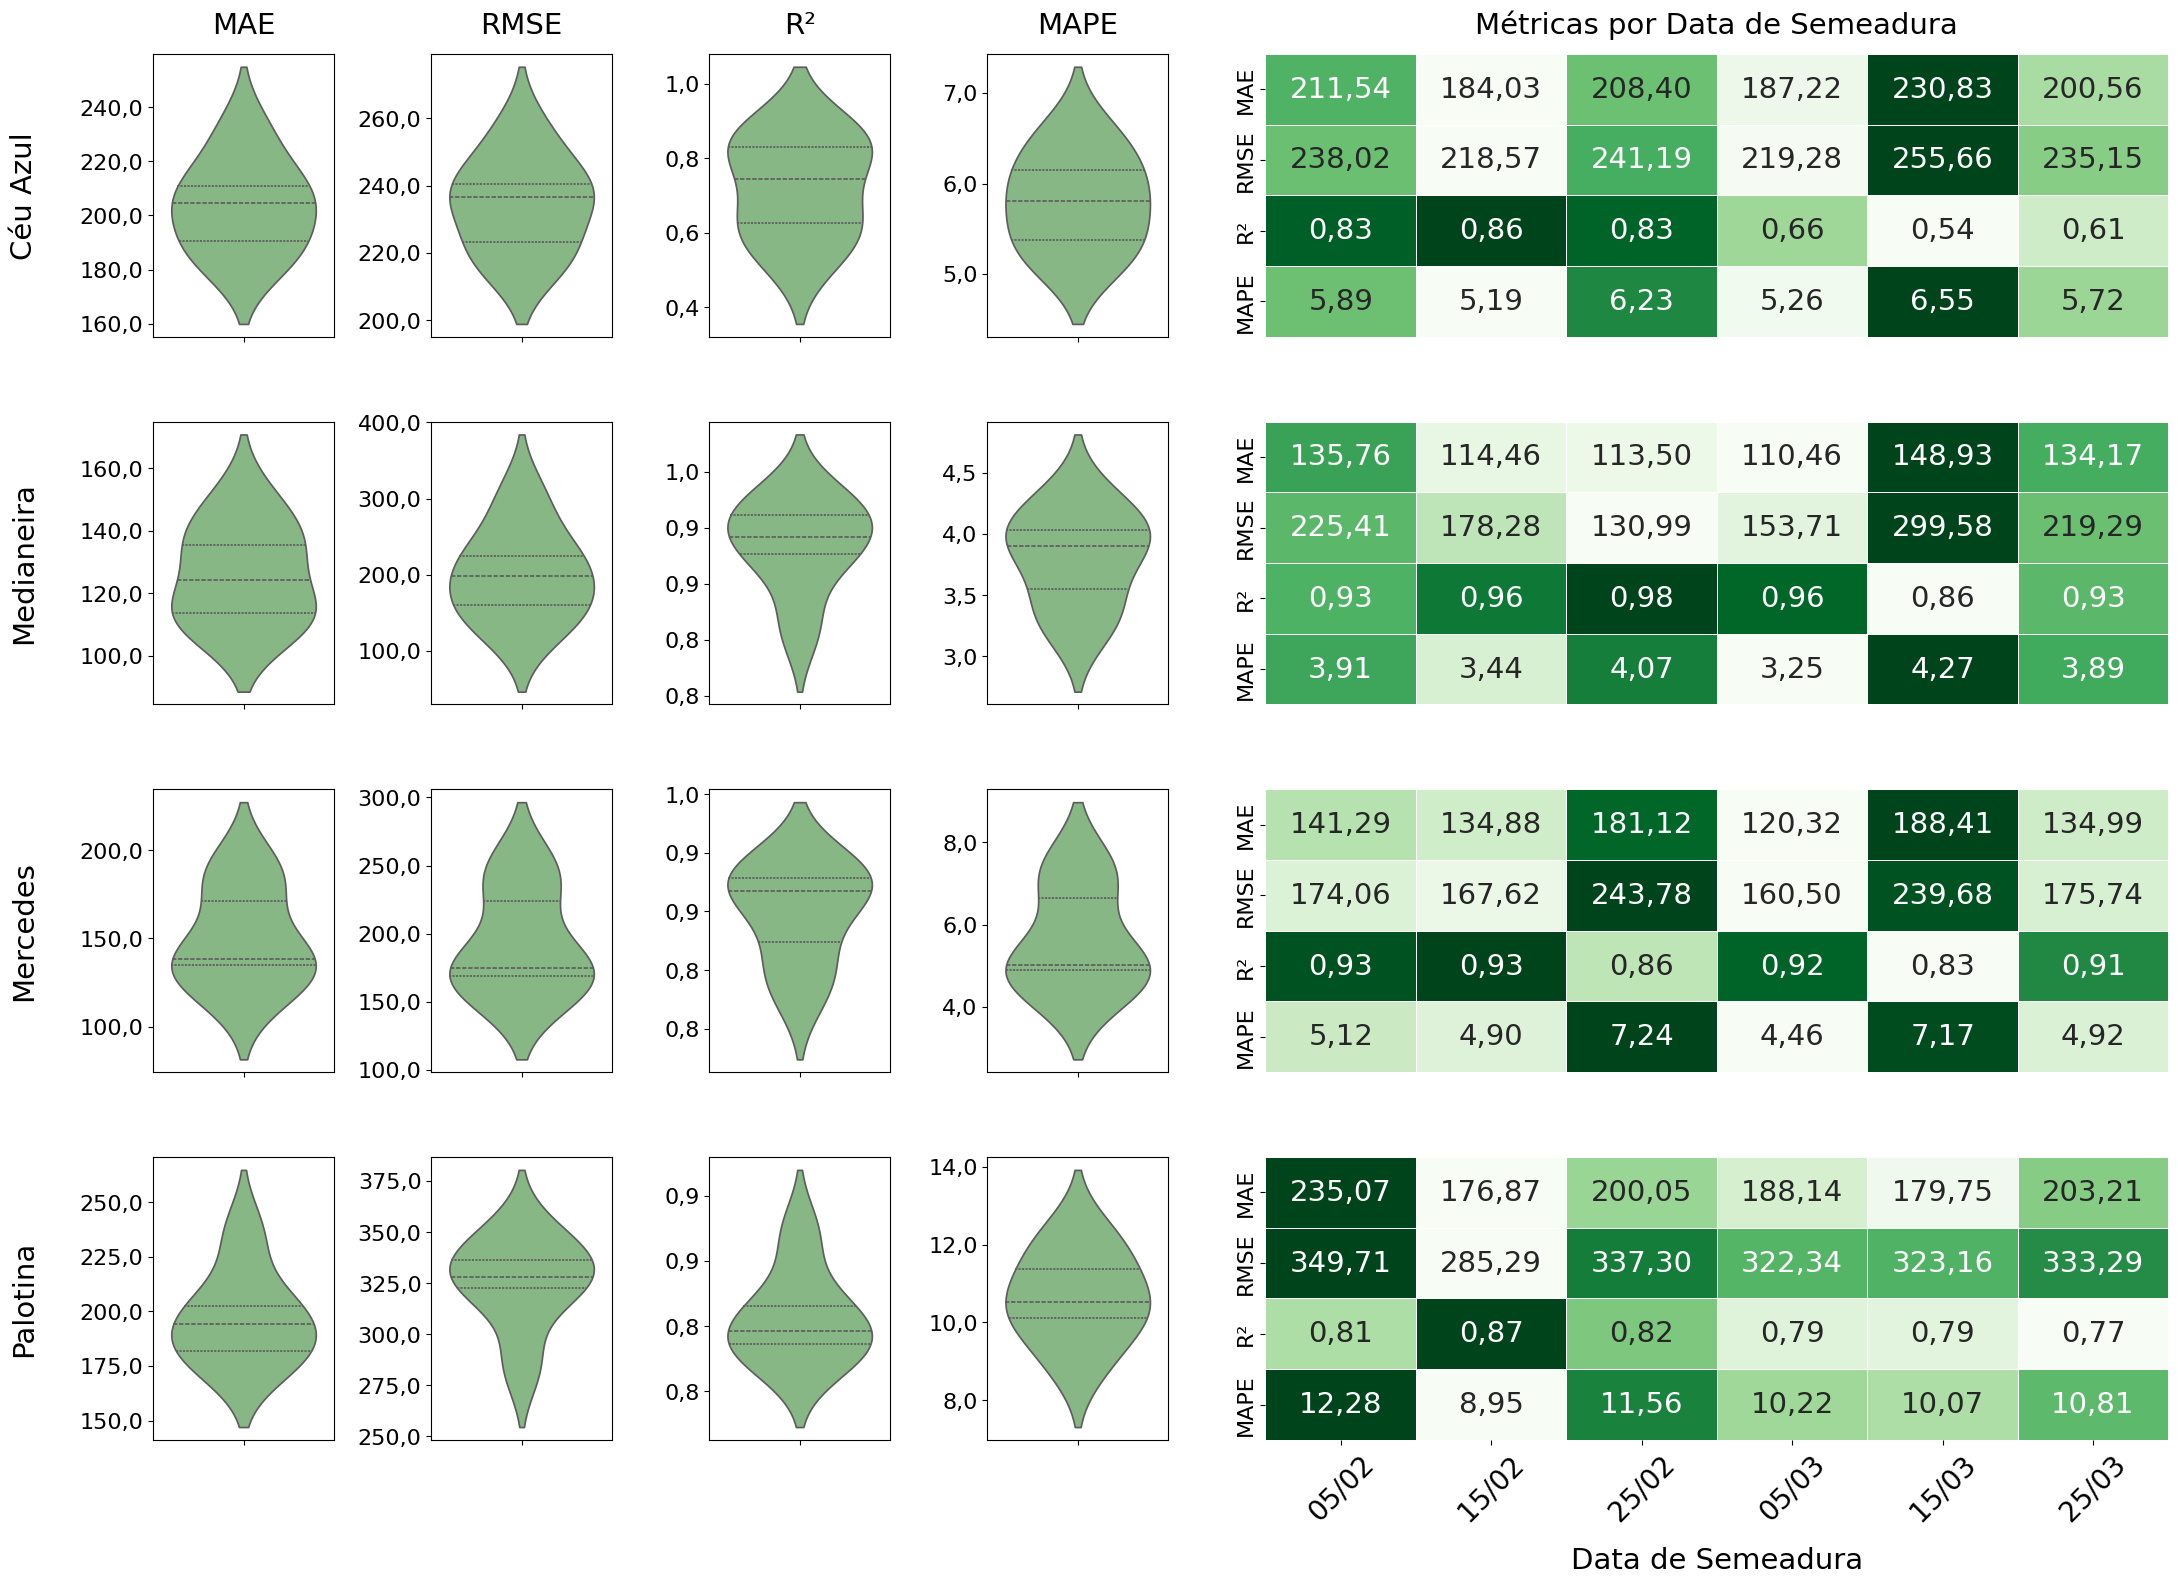

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import MinMaxScaler

# 1. Configuração Global de Tamanho de Fonte 16
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 21,
    'xtick.labelsize': 20,
    'ytick.labelsize': 16
})

# 2. Carregar os dados
df = df_infe
metricas = ['MAE', 'RMSE', 'R²', 'MAPE']
cidades = df['Municipio'].unique()

def format_br(x, pos):
    return f"{x:.1f}".replace('.', ',')

# Configuração do Layout
fig = plt.figure(figsize=(26, 4.5 * len(cidades)))
gs_master = fig.add_gridspec(len(cidades), 5, width_ratios=[0.5, 0.5, 0.5, 0.5, 2.5], hspace=0.3)

for i, cidade in enumerate(cidades):
    df_city = df[df['Municipio'] == cidade].copy()

    # --- VIOLIN PLOTS (Colunas 0 a 3) ---
    for j, metrica in enumerate(metricas):
        ax_v = fig.add_subplot(gs_master[i, j])
        sns.violinplot(y=df_city[metrica], ax=ax_v, color='#7fbf7b', inner="quart")

        if i == 0:
            ax_v.set_title(metrica, pad=15)

        if j == 0:
            ax_v.set_ylabel(cidade, rotation=90, labelpad=30)
        else:
            ax_v.set_ylabel('')

        ax_v.yaxis.set_major_formatter(ticker.FuncFormatter(format_br))

    # --- HEATMAP (Coluna 4) ---
    ax_h = fig.add_subplot(gs_master[i, 4])

    df_heat = df_city.set_index('Data_semeadura')[metricas].T

    # Normalização por linha (métrica) para coloração individual
    scaler = MinMaxScaler()
    df_heat_norm = pd.DataFrame(
        scaler.fit_transform(df_heat.T).T,
        index=df_heat.index,
        columns=df_heat.columns
    )

    # Máscara de texto formatada com vírgula
    annot_text = df_heat.applymap(lambda x: f"{x:.2f}".replace('.', ','))

    # Plotar Heatmap
    sns.heatmap(df_heat_norm, annot=annot_text, fmt="", cmap='Greens',
                ax=ax_h, cbar=False, linewidths=.5,
                annot_kws={"size": 21})

    if i == 0:
        ax_h.set_title('Métricas por Data de Semeadura', pad=15)

    # LOGICA DAS DATAS: Apenas na última linha
    if i == len(cidades) - 1:
        ax_h.set_xlabel('Data de Semeadura', labelpad=15)
        plt.setp(ax_h.get_xticklabels(), rotation=45)
    else:
        ax_h.set_xlabel('')
        ax_h.set_xticks([]) # Remove os ticks (traços) e labels das linhas superiores

    ax_h.set_ylabel('')

plt.subplots_adjust(hspace=0.01, wspace=0.3)
plt.tight_layout()
plt.show()